### EDA Notebook Part 1

In [1]:
# Cella 1: Download dei dati e definizione dell'universo pulito
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Dizionario mappato sui ticker scelti (senza i 4 con missing data)
etf_universe = {
    "SPY": "S&P 500", "QQQ": "Nasdaq-100", "VGK": "Europe", 
    "EWJ": "Japan", "VPL": "Asia-Pacific", "EEM": "MSCI EM", 
    "VWO": "FTSE EM", "SHY": "1-3Y Treasury", "IEF": "7-10Y Treasury", 
    "TLT": "20+Y Treasury", "IGOV": "Intl Treasury", "EMB": "EM Bond USD", 
    "LQD": "IG Corporate", "HYG": "High Yield", "GLD": "Gold", 
    "SLV": "Silver", "DBC": "Broad Commodity", "XLE": "Energy Equity", 
    "TIP": "TIPS", "VNQ": "US REIT", "BIL": "T-Bill (Risk-Free)", "USO": "Oil"
}

tickers = list(etf_universe.keys())

print("Download dei dati in corso...")
prices_daily = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices_daily = prices_daily.dropna(how="all")

print(f"Dimensioni dataset giornaliero: {prices_daily.shape}")

Download dei dati in corso...


[*********************100%***********************]  22 of 22 completed


Dimensioni dataset giornaliero: (4126, 22)


Guida all'Esplorazione dei Dati (EDA) e Analisi dei Rischi Incondizionati
Questa sezione del notebook documenta la fase di Exploratory Data Analysis (EDA) sul nostro universo investibile di 21 ETF. L'obiettivo primario non è solo calcolare metriche standard, ma testare empiricamente le assunzioni teoriche dei modelli di ottimizzazione Media-Varianza e valutare il comportamento degli asset durante i principali stress event sistemici e geopolitici dal 2010 a oggi.

Di seguito viene fornita la chiave di lettura per ogni blocco di analisi e le relative metriche prodotte.

1. Metriche Incondizionate di Rischio e Rendimento
Descrizione del Codice: I prezzi giornalieri vengono ricampionati a fine mese per mitigare il rumore di microstruttura. Vengono calcolati i rendimenti logaritmici continui. La tabella riassume il rendimento annualizzato, la volatilità (deviazione standard annualizzata), l'Indice di Sharpe (utilizzando il T-Bill a 1-3 mesi, BIL, come proxy del tasso risk-free) e il Maximum Drawdown storico.
Cosa ricercare:

Efficienza Risk-Adjusted: Quali asset offrono il miglior Indice di Sharpe storico? (Spesso l'azionario USA predomina, ma è cruciale osservare il posizionamento del credito Investment Grade e dell'oro).

Rischio Estremo: Il Max Drawdown rivela la massima perdita subita da un investitore "sfortunato" che ha comprato sui massimi e venduto sui minimi storici. Le materie prime e gli emergenti tendono ad avere drawdown significativamente peggiori rispetto all'azionario sviluppato.

2. Struttura delle Correlazioni Statiche
Descrizione del Codice: Generazione di una heatmap basata sulla matrice di correlazione di Pearson calcolata sull'intero campione mensile (2010-Oggi).
Cosa ricercare:

Diversificatori Naturali: Si cercano valori vicini allo zero o negativi. Storicamente, i Treasury a lunga scadenza (TLT) e l'oro (GLD) dovrebbero mostrare una correlazione molto bassa o negativa con l'azionario (SPY).

Limiti della Statica: Questa matrice rappresenta una media di lungo periodo. Un errore comune è assumere che queste correlazioni rimangano stabili durante un crollo di mercato.

3. Stress Testing Geopolitico (Correlazioni Dinamiche)
Descrizione del Codice: Calcolo di una rolling correlation (finestra mobile di 60 giorni lavorativi, circa 3 mesi) utilizzando dati giornalieri per massimizzare la reattività. Analizziamo la relazione tra l'S&P 500 e tre proxy di rischio: Oro, Long Treasury e Settore Energetico (sensibile agli shock petroliferi).
Cosa ricercare (Regime Shifts):

Rotture Strutturali: Osservare il comportamento delle linee in prossimità degli eventi geopolitici evidenziati (es. 7 Ottobre).

Flight-to-Quality: Se la correlazione tra SPY e GLD/TLT diventa bruscamente negativa durante uno shock, significa che il mercato sta vendendo azionario per rifugiarsi in asset sicuri. Questa dinamica giustifica l'inclusione di questi asset nel portafoglio nonostante il loro rendimento incondizionato inferiore.

4. Sviluppo della Ricchezza (Cumulative Wealth Index)
Descrizione del Codice: Plot lineare della crescita del capitale (Base 100) per un sottoinsieme rappresentativo di asset (Azionario USA, Bond a lunga scadenza, Oro, Emergenti, Commodities).
Cosa ricercare:

Effetto Compounding: La divergenza delle linee nel lungo termine mostra il potere della capitalizzazione composta.

Impatto degli Shock: Visivamente, quanto sono profondi i "tagli" nella curva durante crisi come il Covid-19 (marzo 2020) o l'invasione dell'Ucraina (febbraio 2022)? Quali asset hanno agito da cuscinetto?

5. Mappatura del Rischio Estremo (Underwater Plot)
Descrizione del Codice: Grafico a riempimento che traccia costantemente la distanza percentuale del prezzo di un asset dal suo massimo storico precedente.
Cosa ricercare:

Profondità vs Durata: Un drawdown non è definito solo da quanto si perde (asse Y), ma anche dal time-to-recovery (asse X). Quanto tempo impiega l'S&P 500 a tornare a quota zero dopo un crollo?

Asincronia: Il momento di massimo drawdown per l'azionario coincide con i massimi dei titoli di stato? Se sì, il portafoglio multi-asset trarrà un enorme beneficio di diversificazione.

6. Dinamica della Volatilità (Volatility Clustering)
Descrizione del Codice: Calcolo della volatilità mobile su una finestra di 6 mesi, confrontata con la volatilità media di lungo periodo.
Cosa ricercare:

Violazione dell'Omoschedasticità: I modelli classici di ottimizzazione assumono che il rischio sia costante. Questo grafico dimostra il fenomeno del volatility clustering: i giorni di forte turbolenza tendono a presentarsi a grappoli.

Contagio: Le linee di volatilità di asset diversi (es. Azionario USA vs Emergenti vs High Yield) tendono a impennarsi simultaneamente durante i sell-off generalizzati.

7. Verifica delle Ipotesi (Test di Normalità e Code Grasse)
Descrizione del Codice: Sovrapposizione della distribuzione empirica (istogramma) dei rendimenti dell'S&P 500 con una curva normale teorica avente la stessa media e varianza.
Cosa ricercare:

Leptocurtosi (Code Grasse): Se l'istogramma presenta un picco centrale più alto e code laterali più "spesse" rispetto alla curva nera, significa che i rendimenti estremi (sia positivi che, criticamente, negativi) avvengono con una frequenza molto superiore a quanto predetto da una distribuzione normale. Ciò implica che l'ottimizzazione Media-Varianza pura tenderà a sottostimare il rischio di coda.

8. Profilo di Dispersione Mensile (Boxplot)
Descrizione del Codice: Boxplot orizzontale dei rendimenti mensili per tutti gli asset, ordinati per volatilità crescente.
Cosa ricercare:

Outliers: I punti esterni ai "baffi" del boxplot rappresentano eventi anomali. L'azionario e le materie prime tendono ad avere outlier fortemente asimmetrici (soprattutto a sinistra, verso le perdite).

Range Interquartile: La larghezza della scatola indica la variabilità standard. Asset come i T-Bill (BIL) o i bond a breve termine avranno scatole quasi invisibili, mentre l'energia (XLE) o gli emergenti avranno una dispersione massiccia.

9. Spazio Rischio-Rendimento Incondizionato
Descrizione del Codice: Scatter plot statico che posiziona ogni ETF nello spazio cartesiano (Asse X = Rischio, Asse Y = Rendimento).
Cosa ricercare:

Asset Dominati: Un asset situato in basso a destra (alto rischio, basso rendimento, es. USO storicamente) è "dominato" e non verrebbe mai incluso in un portafoglio ottimizzato senza vincoli.

Forma della Nuvola: Questo plot rappresenta i "mattoni" grezzi con cui il nostro ottimizzatore (Markowitz o Black-Litterman) costruirà la Frontiera Efficiente, cercando le combinazioni che si spingono verso il quadrante in alto a sinistra  .

In [2]:
# Cella 2: Resampling mensile, log-rendimenti e calcolo metriche storiche
prices_monthly = prices_daily.resample('ME').last()
log_returns_monthly = np.log(prices_monthly / prices_monthly.shift(1)).dropna(how="all")

# Metriche annualizzate
ann_returns = log_returns_monthly.mean() * 12
ann_volatility = log_returns_monthly.std() * np.sqrt(12)

# Sharpe Ratio (utilizziamo BIL come proxy per il tasso risk-free)
risk_free_rate = ann_returns['BIL']
sharpe_ratio = (ann_returns - risk_free_rate) / ann_volatility

# Maximum Drawdown
cumulative_returns = np.exp(log_returns_monthly.cumsum())
running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns / running_max) - 1
max_drawdown = drawdowns.min()

# Creazione DataFrame riassuntivo
eda_metrics = pd.DataFrame({
    'Classe/Asset': pd.Series(etf_universe),
    'Rendimento Ann.': ann_returns,
    'Volatilità Ann.': ann_volatility,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown': max_drawdown
})

display(eda_metrics.round(4).sort_values(by='Sharpe Ratio', ascending=False))

,Classe/Asset,Rendimento Ann.,Volatilità Ann.,Sharpe Ratio,Max Drawdown
QQQ,Nasdaq-100,0.1830,0.1741,0.9770,-0.3258
SPY,S&P 500,0.1373,0.1441,0.8623,-0.2393
HYG,High Yield,0.0532,0.0750,0.5359,-0.1525
VPL,Asia-Pacific,0.0802,0.1524,0.4410,-0.2815
GLD,Gold,0.0839,0.1611,0.4402,-0.4291
VNQ,US REIT,0.0891,0.1733,0.4389,-0.3275
EWJ,Japan,0.0706,0.1432,0.4022,-0.2886
VGK,Europe,0.0754,0.1759,0.3550,-0.3096
LQD,IG Corporate,0.0388,0.0729,0.3537,-0.2326
EMB,EM Bond USD,0.0444,0.0927,0.3384,-0.2674


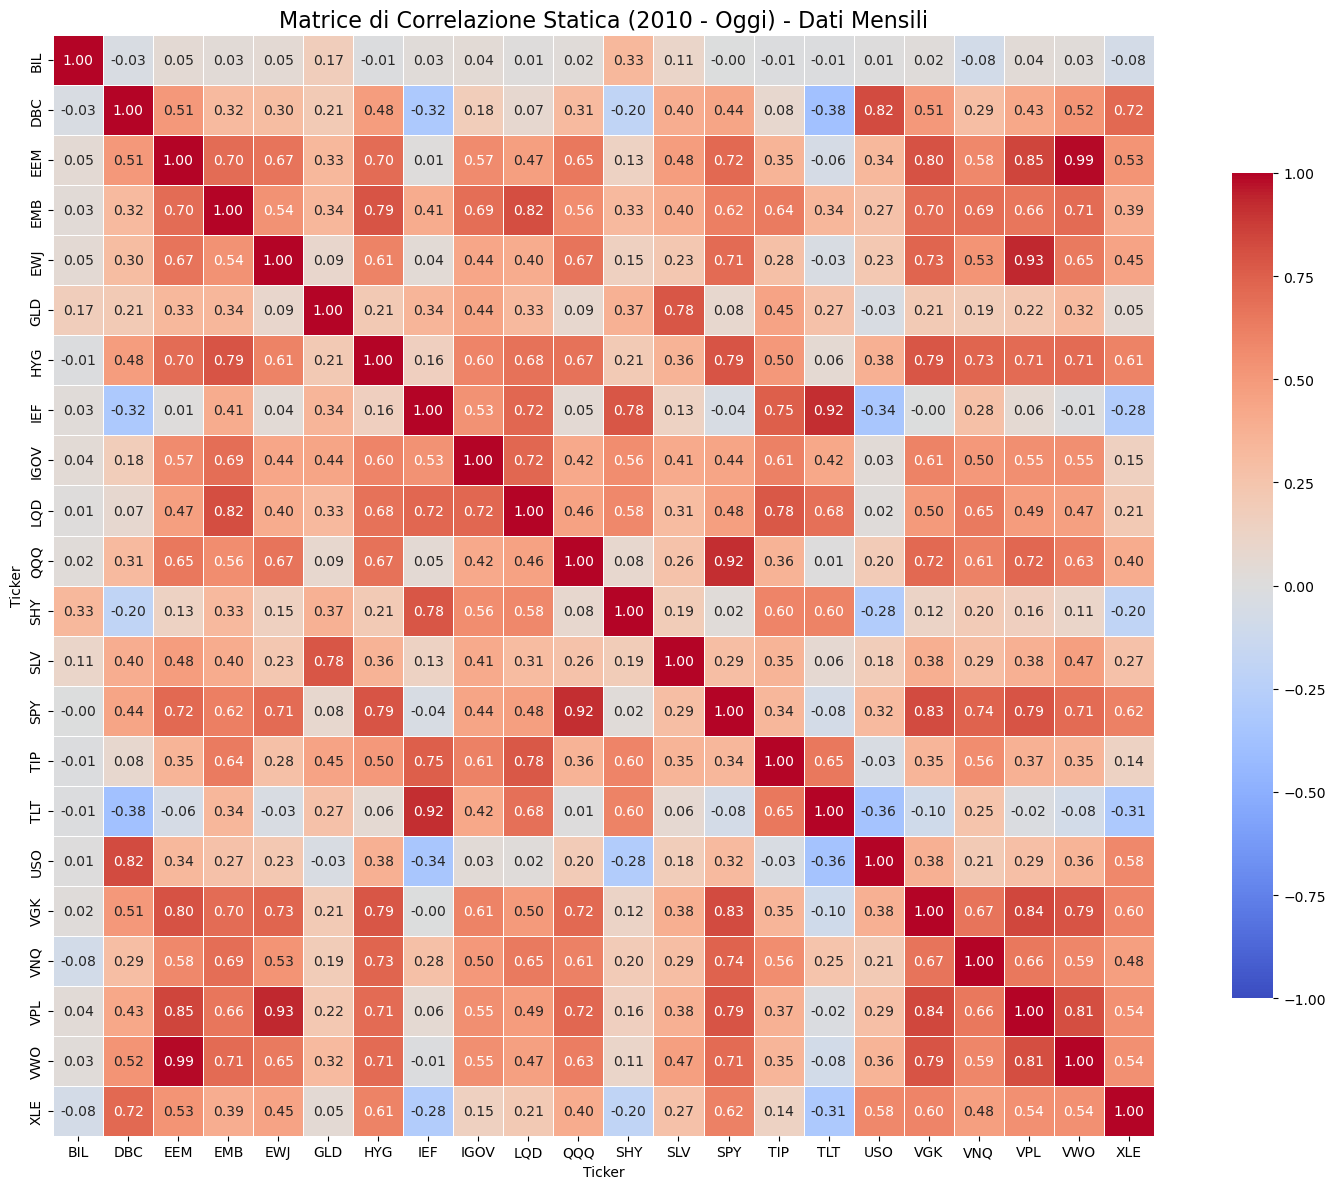

In [3]:
# Cella 3: Matrice di Correlazione di Pearson (Lungo Periodo)
corr_matrix_monthly = log_returns_monthly.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix_monthly, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .75}
)
plt.title("Matrice di Correlazione Statica (2010 - Oggi) - Dati Mensili", fontsize=16)
plt.tight_layout()
plt.show()

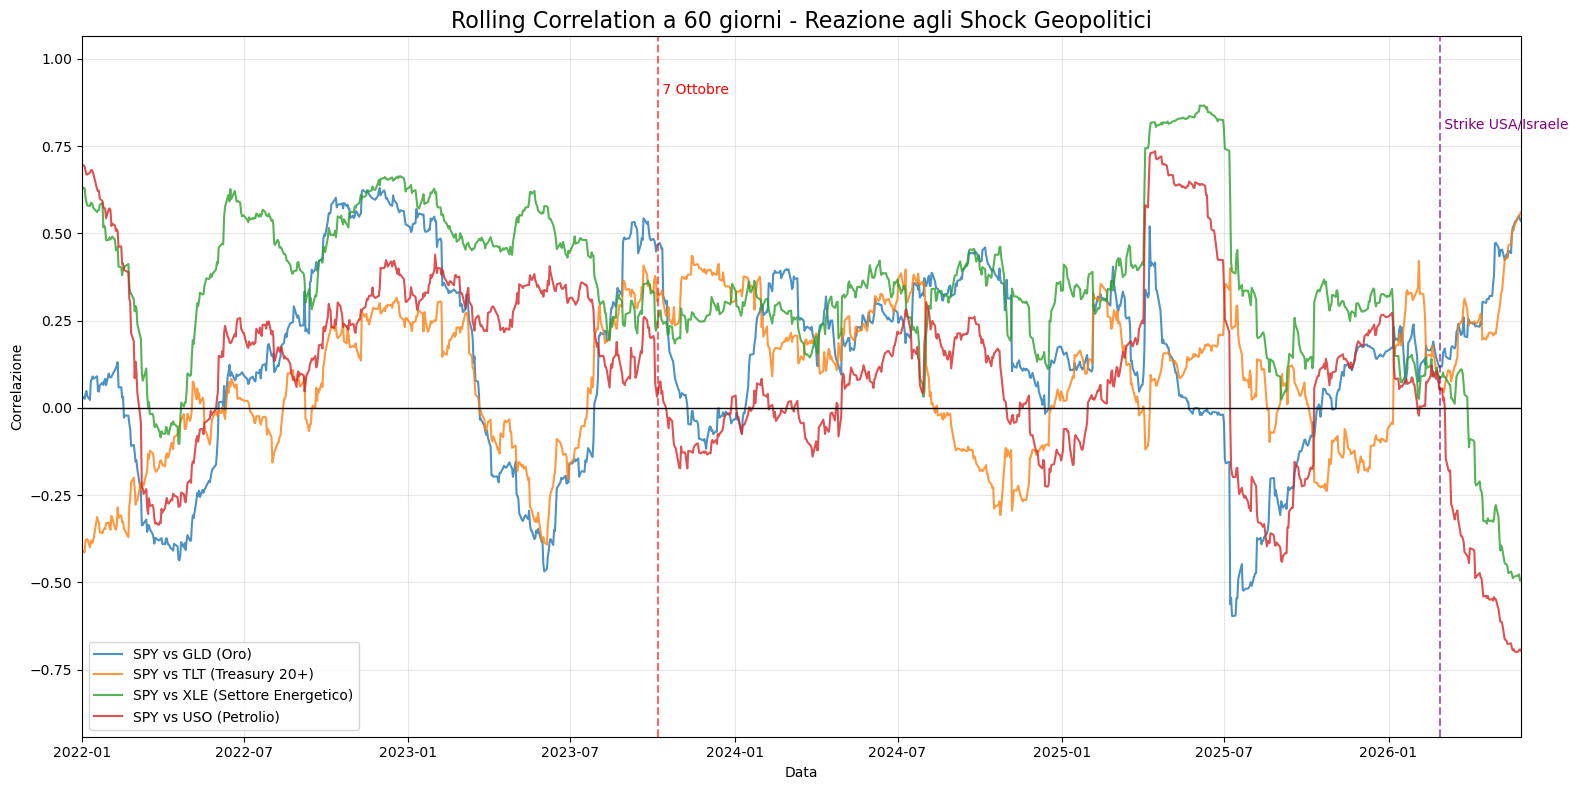

In [5]:
# Cella 4: Regime Shift e Rolling Correlation (Dati Giornalieri)
log_returns_daily = np.log(prices_daily / prices_daily.shift(1)).dropna(how="all")
window = 60

# Calcolo correlazione mobile rispetto allo S&P 500
rolling_corr_gld = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['GLD'])
rolling_corr_tlt = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['TLT'])
# Utilizziamo XLE (Energy Equity) come proxy della reattività energetica
rolling_corr_xle = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['XLE'])
rolling_corr_uso = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['USO'])

plt.figure(figsize=(16, 8))
plt.plot(rolling_corr_gld, label='SPY vs GLD (Oro)', alpha=0.8, linewidth=1.5)
plt.plot(rolling_corr_tlt, label='SPY vs TLT (Treasury 20+)', alpha=0.8, linewidth=1.5)
plt.plot(rolling_corr_xle, label='SPY vs XLE (Settore Energetico)', alpha=0.8, linewidth=1.5)
plt.plot(rolling_corr_uso, label='SPY vs USO (Petrolio)', alpha=0.8, linewidth=1.5)

# Eventi geopolitici storici
plt.axvline(pd.to_datetime('2023-10-07'), color='red', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2023-10-07'), 0.9, ' 7 Ottobre', color='red')

# Nuove date relative alla Crisi di Hormuz del 2026
plt.axvline(pd.to_datetime('2026-02-28'), color='purple', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2026-02-28'), 0.8, ' Strike USA/Israele', color='purple')


plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title("Rolling Correlation a 60 giorni - Reazione agli Shock Geopolitici", fontsize=16)
plt.xlabel("Data")
plt.ylabel("Correlazione")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# Estendiamo l'asse x per includere i dati fino a oggi (Maggio 2026)
plt.xlim(pd.to_datetime('2022-01-01'), log_returns_daily.index[-1])
plt.tight_layout()
plt.show()

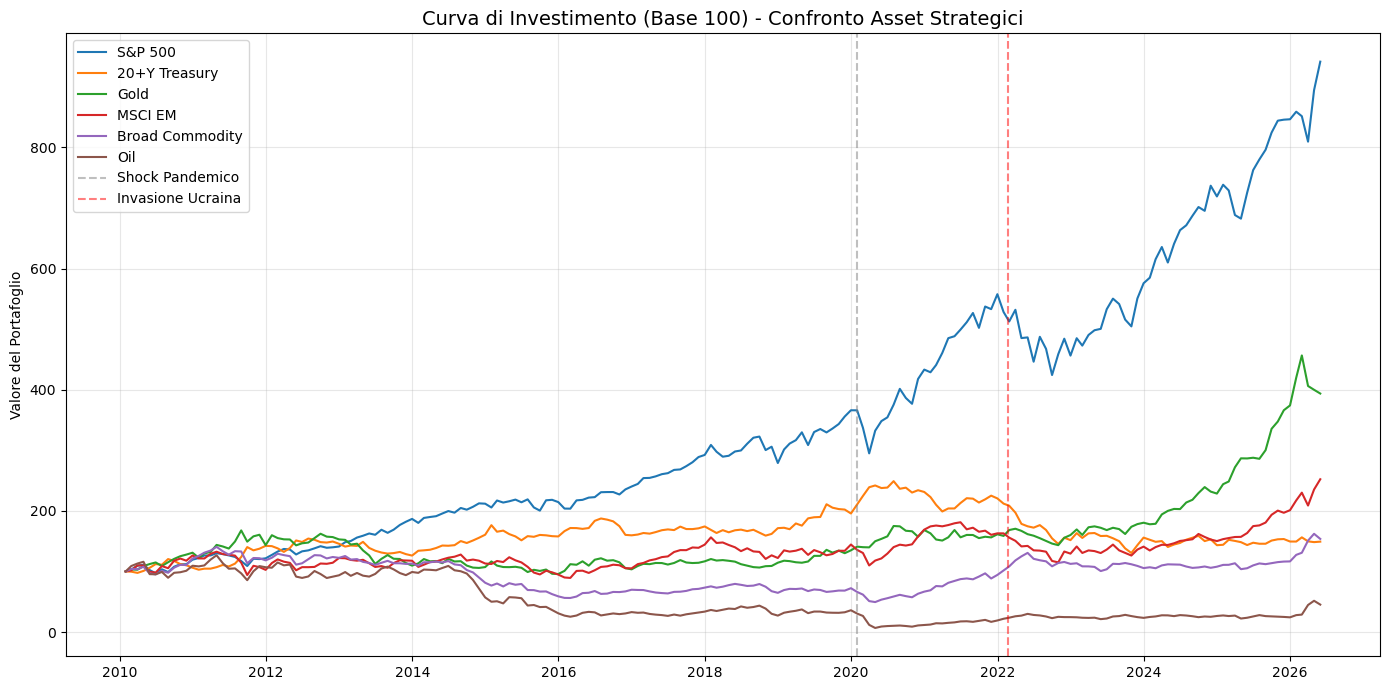

In [6]:
# Cella 5: Cumulative Wealth Index (Base 100)
sample_tickers = ['SPY', 'TLT', 'GLD', 'EEM', 'DBC', "USO"]

cumulative_wealth = 100 * np.exp(log_returns_monthly[sample_tickers].cumsum())
cumulative_wealth.loc[prices_monthly.index[0]] = 100
cumulative_wealth = cumulative_wealth.sort_index()

plt.figure(figsize=(14, 7))
for ticker in sample_tickers:
    plt.plot(cumulative_wealth.index, cumulative_wealth[ticker], label=etf_universe[ticker], linewidth=1.5)

plt.axvline(pd.to_datetime('2020-02-01'), color='gray', linestyle='--', alpha=0.5, label='Shock Pandemico')
plt.axvline(pd.to_datetime('2022-02-24'), color='red', linestyle='--', alpha=0.5, label='Invasione Ucraina')

plt.title("Curva di Investimento (Base 100) - Confronto Asset Strategici", fontsize=14)
plt.ylabel("Valore del Portafoglio")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

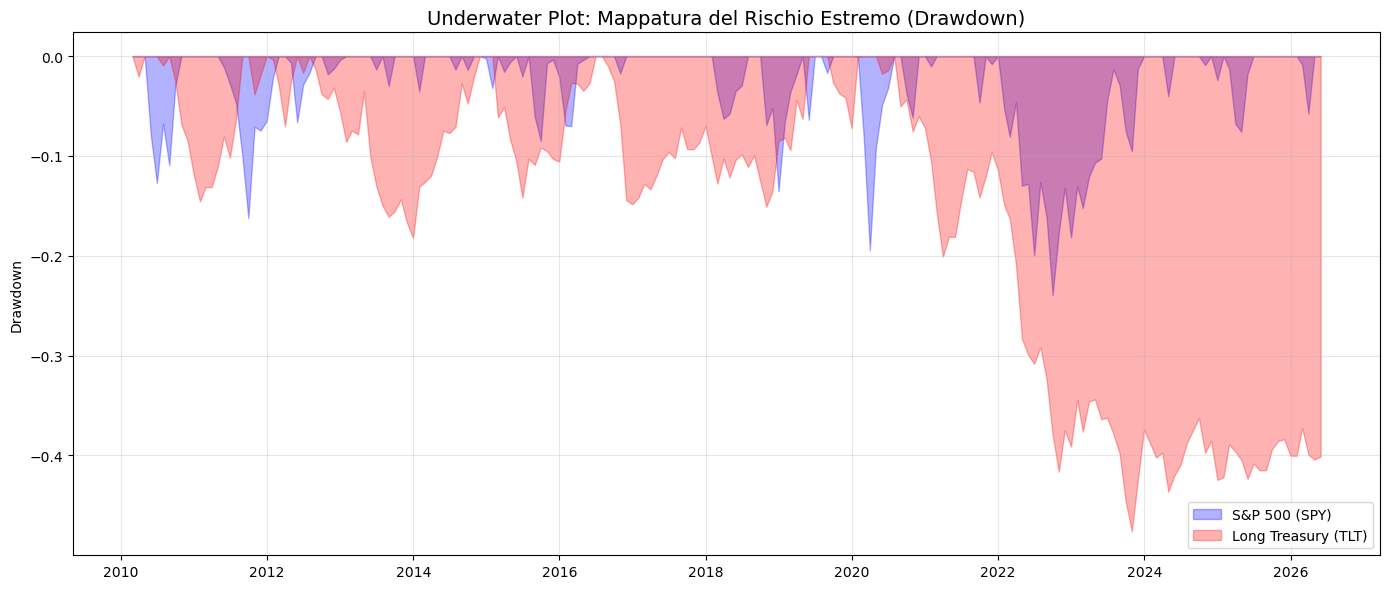

In [7]:
# Cella 6: Underwater Plot 
cum_returns_all = np.exp(log_returns_monthly.cumsum())
running_max_all = cum_returns_all.cummax()
drawdowns_all = (cum_returns_all / running_max_all) - 1

plt.figure(figsize=(14, 6))
plt.fill_between(drawdowns_all.index, drawdowns_all['SPY'], 0, color='blue', alpha=0.3, label='S&P 500 (SPY)')
plt.fill_between(drawdowns_all.index, drawdowns_all['TLT'], 0, color='red', alpha=0.3, label='Long Treasury (TLT)')

plt.title("Underwater Plot: Mappatura del Rischio Estremo (Drawdown)", fontsize=14)
plt.ylabel("Drawdown")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

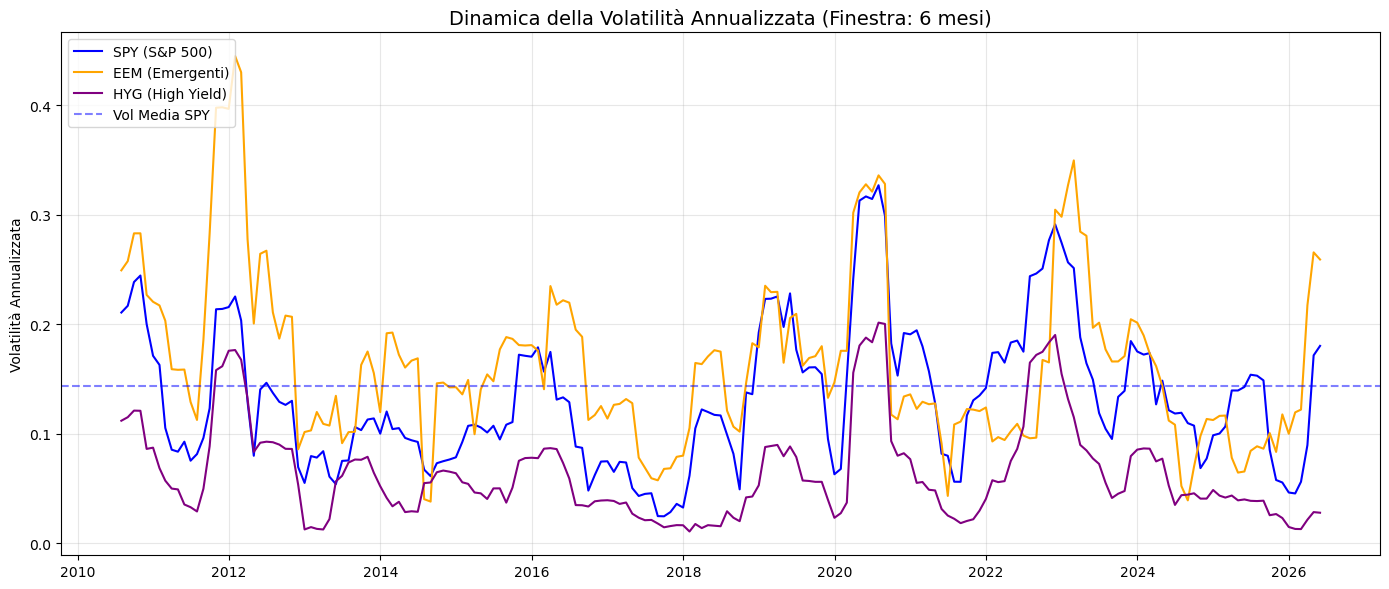

In [8]:
# Cella 7: Rolling Volatility Annualizzata (Finestra a 6 mesi)
window_months = 6
rolling_vol = log_returns_monthly[['SPY', 'EEM', 'HYG']].rolling(window=window_months).std() * np.sqrt(12)

plt.figure(figsize=(14, 6))
plt.plot(rolling_vol['SPY'], label='SPY (S&P 500)', color='blue')
plt.plot(rolling_vol['EEM'], label='EEM (Emergenti)', color='orange')
plt.plot(rolling_vol['HYG'], label='HYG (High Yield)', color='purple')

plt.axhline(ann_volatility['SPY'], color='blue', linestyle='--', alpha=0.5, label='Vol Media SPY')
plt.title(f"Dinamica della Volatilità Annualizzata (Finestra: {window_months} mesi)", fontsize=14)
plt.ylabel("Volatilità Annualizzata")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

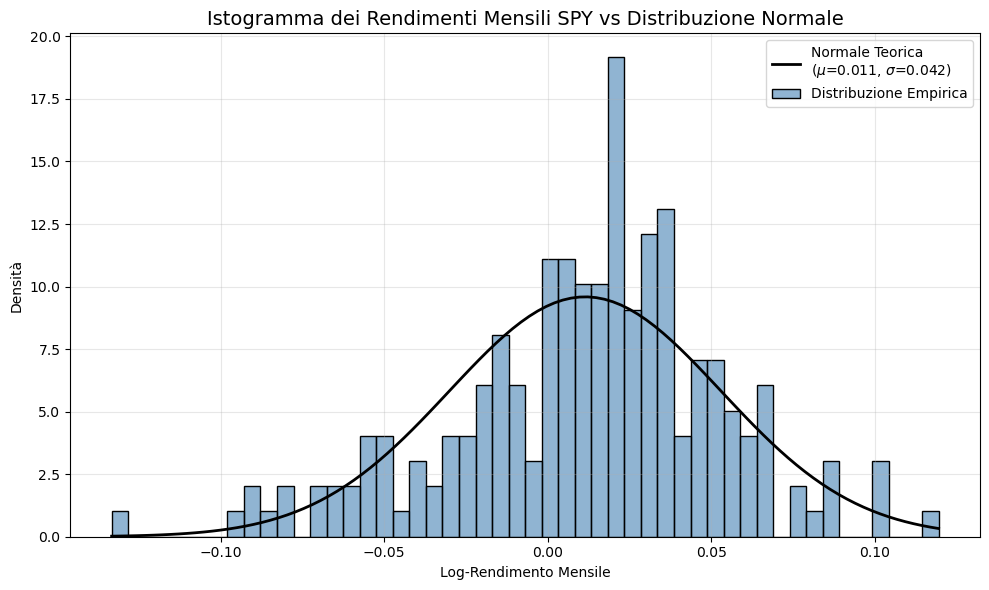

In [9]:
# Cella 8: Code Grasse e Asimmetria dei Rendimenti
spy_returns = log_returns_monthly['SPY'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(spy_returns, bins=50, stat='density', alpha=0.6, color='steelblue', label='Distribuzione Empirica')

mu, std = spy_returns.mean(), spy_returns.std()
x = np.linspace(spy_returns.min(), spy_returns.max(), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normale Teorica\n($\mu$={mu:.3f}, $\sigma$={std:.3f})')

plt.title("Istogramma dei Rendimenti Mensili SPY vs Distribuzione Normale", fontsize=14)
plt.xlabel("Log-Rendimento Mensile")
plt.ylabel("Densità")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

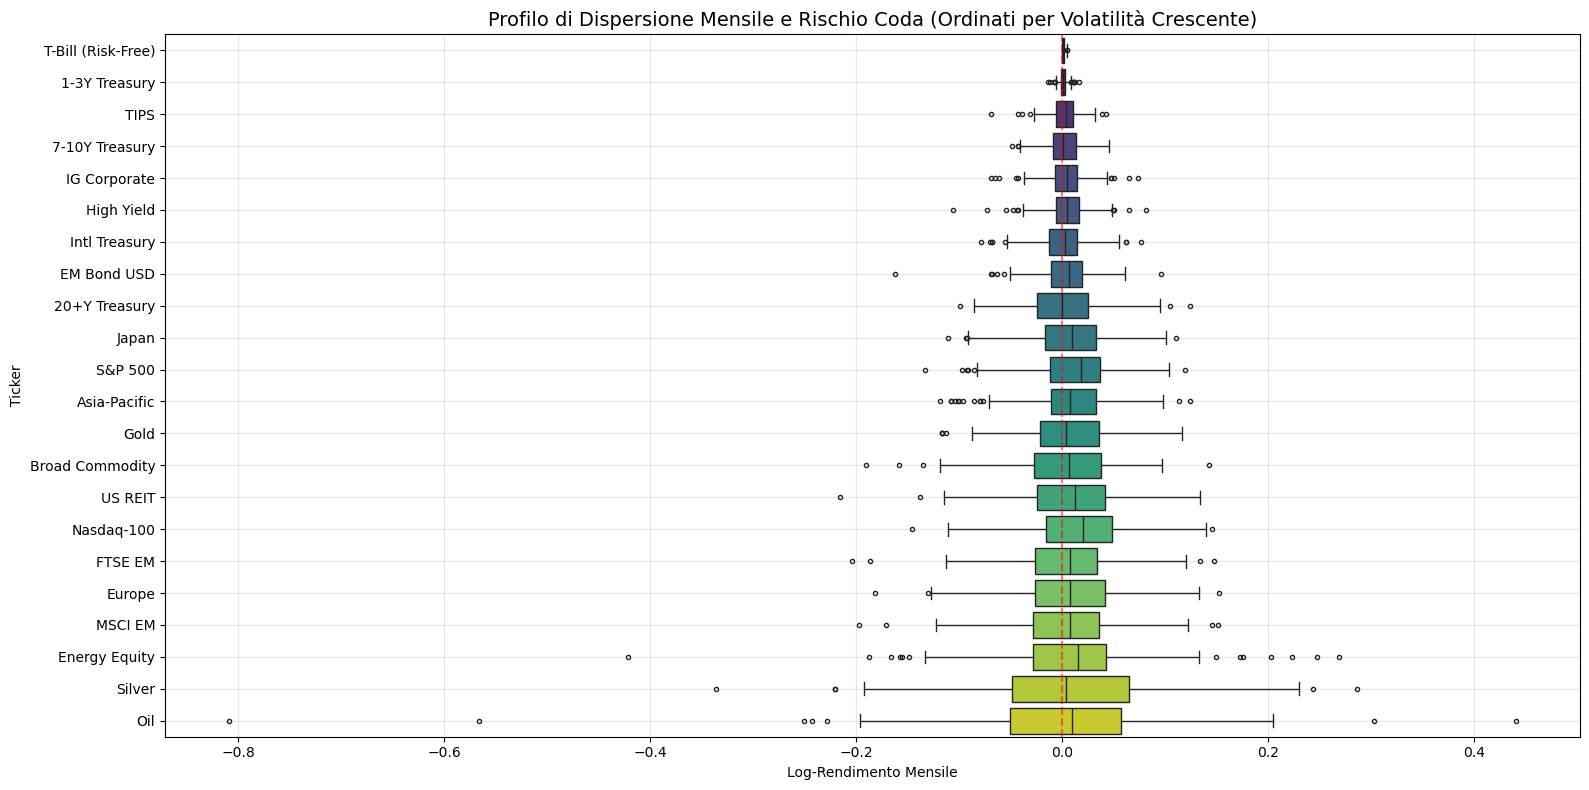

In [10]:
# Cella 9: Boxplot della Dispersione Mensile
plt.figure(figsize=(16, 8))
sorted_tickers = ann_volatility.sort_values().index

sns.boxplot(data=log_returns_monthly[sorted_tickers], orient='h', palette='viridis', fliersize=3)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

# Sostituiamo le label dell'asse y con i nomi estesi per leggibilità
plt.yticks(ticks=range(len(sorted_tickers)), labels=[etf_universe[t] for t in sorted_tickers])

plt.title("Profilo di Dispersione Mensile e Rischio Coda (Ordinati per Volatilità Crescente)", fontsize=14)
plt.xlabel("Log-Rendimento Mensile")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

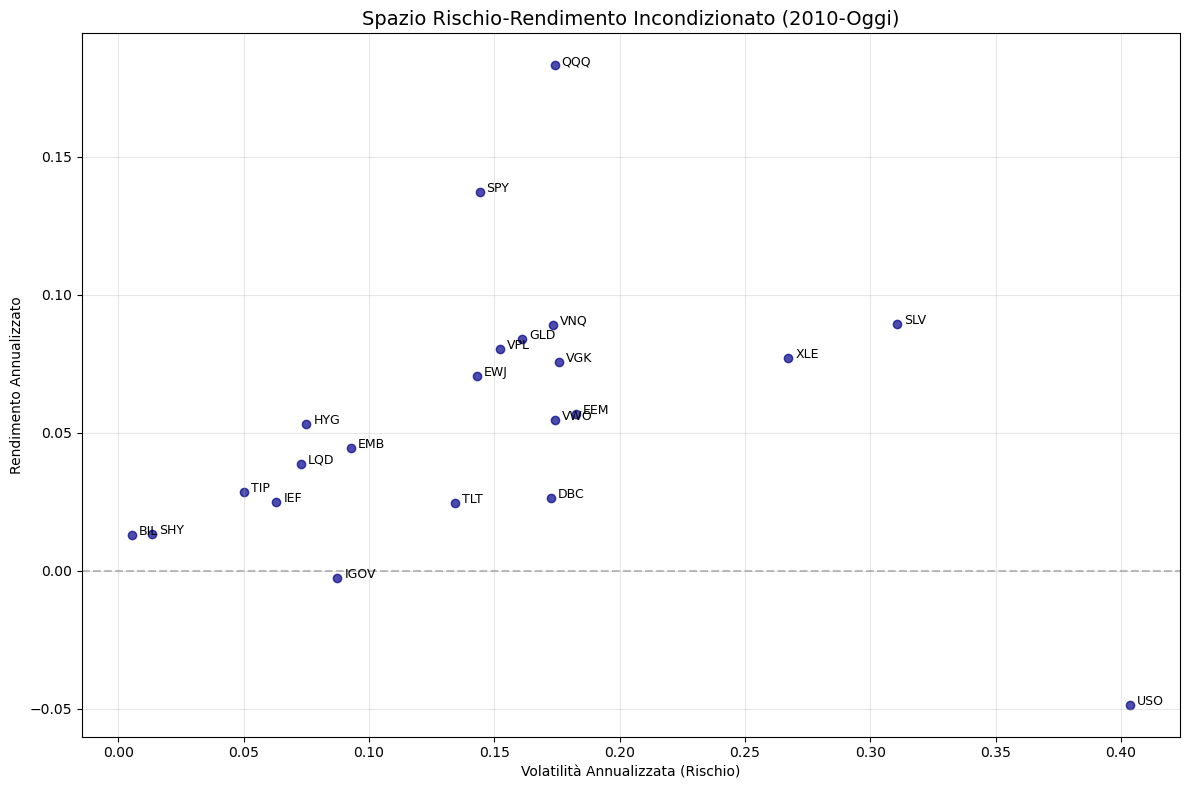

In [11]:
# Cella 10: Scatter Plot Rischio-Rendimento
plt.figure(figsize=(12, 8))
plt.scatter(ann_volatility, ann_returns, alpha=0.7, color='darkblue')

for ticker in tickers:
    plt.annotate(
        ticker, 
        (ann_volatility[ticker], ann_returns[ticker]), 
        xytext=(5, 0), 
        textcoords='offset points',
        fontsize=9
    )

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("Spazio Rischio-Rendimento Incondizionato (2010-Oggi)", fontsize=14)
plt.xlabel("Volatilità Annualizzata (Rischio)")
plt.ylabel("Rendimento Annualizzato")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()